In [1]:
import arviz as az
import pandas as pd

In [2]:
cd ../

In [3]:
def count_bad_rhat(idata, var_names = None):
    summary_df = az.summary(idata, var_names = var_names)
    high_rhat_params = summary_df[summary_df['r_hat'] > 1.01]
    num_high_rhat_params = len(high_rhat_params)
    worst_rhat = summary_df['r_hat'].max()
    return num_high_rhat_params, worst_rhat
def count_divergences(idata):
    return idata.sample_stats.diverging.sum().item()

def get_bfmi(idata):
    return az.bfmi(idata) 

def get_min_ess(idata, var_names = None):
    ess = az.ess(idata, var_names = var_names)
    min_ess = float('inf')
    for var in ess.data_vars:
        var_min_ess = ess[var].min().item()
        if var_min_ess < min_ess:
            min_ess = var_min_ess
    return min_ess

In [4]:
model_dict = {}
model_dict['mrp_soc_dem_uk'] = az.from_netcdf('./idata/uk/rsv_intent_ord_soc.nc')
model_dict['rct'] = az.from_netcdf('./idata/uk/rsv_intent_causal_w_soc_ordinal_treat.nc')
model_dict['rct_varying_c'] = az.from_netcdf('./idata/uk/rsv_intent_causal_w_soc.nc')
model_dict['rct_varying_c_old'] = az.from_netcdf('./idata/uk/rsv_intent_causal_w_soc_varying_cutpoints_v1.nc')
model_dict['child_cond_pre_post'] = az.from_netcdf('./idata/uk/child_cond_on_pre_and_post.nc')
model_dict['besd'] = az.from_netcdf('./idata/ew/rsv_intent_besd_soc.nc')
model_dict['soc_dem'] = az.from_netcdf('./idata/ew/rsv_intent_ord_soc_wo_micro.nc')

In [3]:
idata = az.from_netcdf('./idata/uk/child_cond_on_pre_and_post.nc')

In [5]:
idata.posterior['y_log_prob_child_treat'].values.shape

(4, 500, 1519, 4, 4, 4, 7)

In [6]:
az.summary(idata, var_names = ['beta_treat_child','sigma_treat_child'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_treat_child[0],0.046,0.099,-0.124,0.256,0.002,0.002,1972.0,2011.0,1.0
beta_treat_child[1],0.034,0.097,-0.139,0.234,0.002,0.002,1748.0,1924.0,1.0
beta_treat_child[2],0.019,0.094,-0.170,0.205,0.002,0.001,2102.0,1797.0,1.0
beta_treat_child[3],0.051,0.100,-0.114,0.273,0.002,0.002,1789.0,1787.0,1.0
beta_treat_child[4],-0.050,0.105,-0.281,0.127,0.002,0.002,2056.0,1721.0,1.0
beta_treat_child[5],-0.037,0.100,-0.255,0.135,0.002,0.002,1817.0,1974.0,1.0
beta_treat_child[6],-0.063,0.108,-0.297,0.108,0.003,0.002,1720.0,1873.0,1.0
sigma_treat_child,0.124,0.103,0.000,0.300,0.002,0.002,1795.0,2057.0,1.0


In [6]:
idata.posterior['beta_treat_child'].values.reshape(2000,-1).shape

(2000, 7)

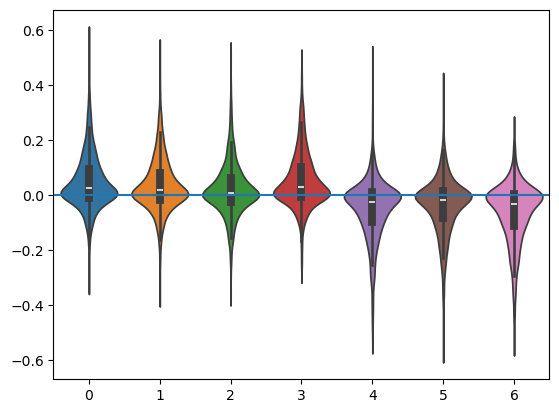

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
sns.violinplot( pd.DataFrame(idata.posterior['beta_treat_child'].values.reshape(2000,-1)), ax = ax )
ax.axhline(0)

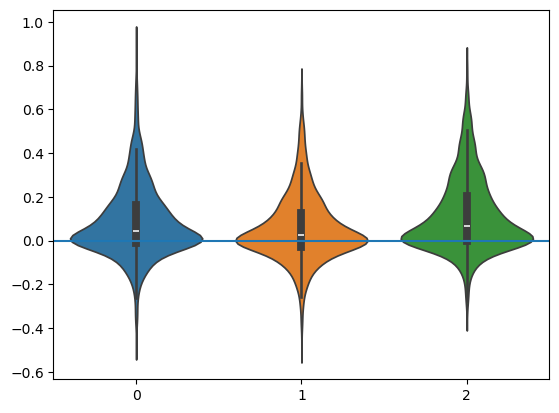

In [8]:
fig, ax = plt.subplots()
sns.violinplot( pd.DataFrame(idata.posterior['beta_treat_child'].values.reshape(2000,-1)[:,1:4] - idata.posterior['beta_treat_child'].values.reshape(2000,-1)[:,4:]), ax = ax )
ax.axhline(0)

In [5]:
results = []
for model_name, idata in model_dict.items():
    posterior_vars = list(idata.posterior.data_vars)
    var_names = [v for v in posterior_vars if v not in ['y_log_prob','y_pred', 'y_log_prob_child', 'y_log_prob_pre', 'y_log_prob_post', 'y_log_prob_child_treat', 'y_log_prob_post_treat' ] ]
    var_names = [v for v in var_names if 'raw' not in v]
    
    new_results = {'Model' : model_name}
    num_bad_rhat, worst_rhat = count_bad_rhat(idata, var_names = var_names)
    new_results['Number R_hat > 1.01'] = num_bad_rhat
    new_results['Largest R_hat'] = worst_rhat
    new_results['Number of divergences'] = count_divergences(idata)
    new_results['Minimum ESS'] = get_min_ess(idata, var_names = var_names)
    bfmi = get_bfmi(idata)
    for i, _bfmi in enumerate(bfmi):
        new_results[f'BFMI chain {i+1}'] = _bfmi
    print(new_results)
    results.append(new_results.copy())

{'Model': 'mrp_soc_dem_uk', 'Number R_hat > 1.01': 0, 'Largest R_hat': 1.0, 'Number of divergences': 0, 'Minimum ESS': 1596.2639547013687, 'BFMI chain 1': 1.784983373821534, 'BFMI chain 2': 1.6460549018597541, 'BFMI chain 3': 1.8042368433491003, 'BFMI chain 4': 1.7510565603460015}
{'Model': 'rct', 'Number R_hat > 1.01': 0, 'Largest R_hat': 1.01, 'Number of divergences': 0, 'Minimum ESS': 1296.6484856881084, 'BFMI chain 1': 1.8044589959924373, 'BFMI chain 2': 1.738112521118466, 'BFMI chain 3': 1.7680908173711811, 'BFMI chain 4': 1.9222429791442583}
{'Model': 'rct_varying_c', 'Number R_hat > 1.01': 0, 'Largest R_hat': 1.0, 'Number of divergences': 0, 'Minimum ESS': 1402.552344326645, 'BFMI chain 1': 1.6902775454377725, 'BFMI chain 2': 1.8154329479947366, 'BFMI chain 3': 1.7819854947764597, 'BFMI chain 4': 1.8529904060965854}
{'Model': 'rct_varying_c_old', 'Number R_hat > 1.01': 0, 'Largest R_hat': 1.01, 'Number of divergences': 0, 'Minimum ESS': 1444.4250747034348, 'BFMI chain 1': 1.9537

In [6]:
model_diagnostics_df = pd.DataFrame(results)
model_diagnostics_df = model_diagnostics_df.set_index('Model')
model_diagnostics_df

,Number R_hat > 1.01,Largest R_hat,Number of divergences,Minimum ESS,BFMI chain 1,BFMI chain 2,BFMI chain 3,BFMI chain 4
Model,,,,,,,,
mrp_soc_dem_uk,0,1.00,0,1596.263955,1.784983,1.646055,1.804237,1.751057
rct,0,1.01,0,1296.648486,1.804459,1.738113,1.768091,1.922243
rct_varying_c,0,1.00,0,1402.552344,1.690278,1.815433,1.781985,1.852990
rct_varying_c_old,0,1.01,0,1444.425075,1.953768,1.648652,1.747308,1.769888
child_cond_pre_post,0,1.01,0,1424.268117,1.907178,1.788418,1.858413,1.939935
besd,0,1.00,0,1189.858477,1.746103,1.670972,2.010421,1.850326
soc_dem,0,1.00,0,1426.232033,1.856797,1.909889,1.914263,1.783957


In [7]:
az.summary(model_dict['rct_varying_c'], var_names = ['c_tilde_prior'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"c_tilde_prior[0, 0]",1.580,0.679,0.429,2.810,0.015,0.011,2051.0,1931.0,1.0
"c_tilde_prior[0, 1]",2.799,1.294,0.740,5.250,0.029,0.020,2034.0,2130.0,1.0
"c_tilde_prior[1, 0]",3.340,1.455,1.083,6.246,0.035,0.025,1706.0,1895.0,1.0
"c_tilde_prior[1, 1]",1.880,0.789,0.521,3.228,0.018,0.013,1830.0,1938.0,1.0
"c_tilde_prior[2, 0]",1.916,0.802,0.568,3.447,0.018,0.013,1920.0,1800.0,1.0
"c_tilde_prior[2, 1]",3.361,1.493,0.938,6.096,0.035,0.025,1922.0,1693.0,1.0
"c_tilde_prior[3, 0]",1.660,0.724,0.413,2.972,0.016,0.011,2139.0,1933.0,1.0
"c_tilde_prior[3, 1]",3.394,1.523,0.926,6.325,0.035,0.024,1889.0,1932.0,1.0


In [9]:
az.summary(model_dict['rct_varying_c'], var_names = ['c_tilde_prior', 'c_tilde_prior_scale'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"c_tilde_prior[0, 0]",0.377,0.086,0.221,0.539,0.002,0.001,2272.0,1971.0,1.0
"c_tilde_prior[0, 1]",0.623,0.086,0.461,0.779,0.002,0.001,2272.0,1971.0,1.0
"c_tilde_prior[1, 0]",0.626,0.084,0.471,0.781,0.002,0.001,2025.0,2055.0,1.0
"c_tilde_prior[1, 1]",0.374,0.084,0.219,0.529,0.002,0.001,2025.0,2055.0,1.0
"c_tilde_prior[2, 0]",0.371,0.083,0.221,0.516,0.002,0.001,2119.0,1962.0,1.0
"c_tilde_prior[2, 1]",0.629,0.083,0.484,0.779,0.002,0.001,2119.0,1962.0,1.0
"c_tilde_prior[3, 0]",0.345,0.083,0.202,0.507,0.002,0.001,1944.0,1893.0,1.0
"c_tilde_prior[3, 1]",0.655,0.083,0.493,0.798,0.002,0.001,1944.0,1893.0,1.0
c_tilde_prior_scale[0],3.680,1.701,0.941,6.745,0.039,0.027,1870.0,1828.0,1.0
c_tilde_prior_scale[1],4.278,1.950,1.209,7.877,0.045,0.032,1862.0,1823.0,1.0


In [16]:
az.summary(model_dict['rct'], var_names = ['beta_eth_pre'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_eth_pre[0],-0.022,0.025,-0.068,0.026,0.001,0.0,1922.0,1747.0,1.0
beta_eth_pre[1],0.022,0.025,-0.026,0.068,0.001,0.0,1922.0,1747.0,1.0


In [10]:
model_dict.keys()

dict_keys(['mrp_soc_dem_uk', 'rct', 'rct_varying_c', 'rct_varying_c_old', 'child_cond_pre_post', 'besd', 'soc_dem'])

In [11]:
az.compare({'rct_c_v0' : model_dict['rct_varying_c_old'], 'rct_c' : model_dict['rct_varying_c']})

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
rct_c_v0,0,-7244.298809,197.93666,0.00000,0.962417,88.887995,0.00000,False,log
rct_c,1,-7244.406069,198.51115,0.10726,0.037583,88.858720,0.48166,False,log


In [10]:
model_diagnostics_df = pd.DataFrame(results)
model_diagnostics_df = model_diagnostics_df.set_index('Model')
model_diagnostics_df

,Number R_hat > 1.01,Largest R_hat,Number of divergences,Minimum ESS,BFMI chain 1,BFMI chain 2,BFMI chain 3,BFMI chain 4
Model,,,,,,,,
mrp_soc_dem_uk,0,1.00,0,1596.263955,1.784983,1.646055,1.804237,1.751057
rct,0,1.01,0,1296.648486,1.804459,1.738113,1.768091,1.922243
_rct,0,1.01,1,478.282002,0.636486,0.687234,0.802239,0.706870
child_cond_pre_post,0,1.01,11,888.438212,1.779564,1.695397,1.681324,1.614097
besd,0,1.00,0,1189.858477,1.746103,1.670972,2.010421,1.850326
_besd,0,1.01,1,380.501903,0.770774,0.690841,0.985021,0.871818
soc_dem,0,1.00,0,1426.232033,1.856797,1.909889,1.914263,1.783957


<Axes: >

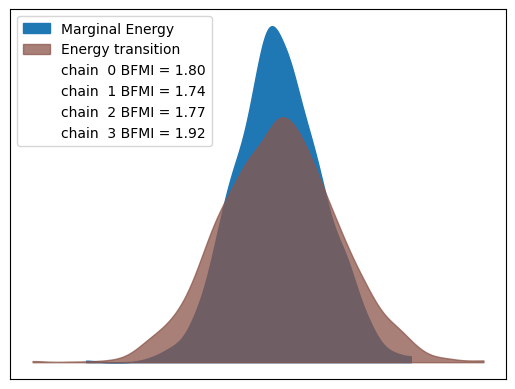

In [36]:
az.plot_energy(model_dict['rct'])

<Axes: >

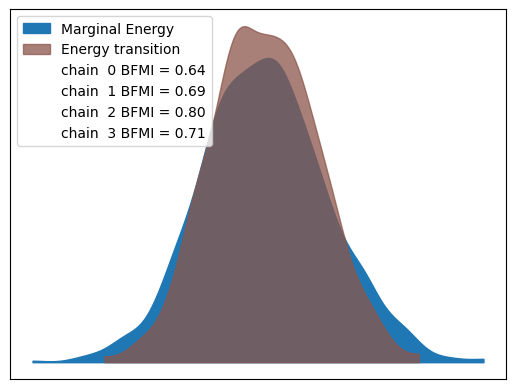

In [37]:
az.plot_energy(model_dict['_rct'])

array([<Axes: title={'center': 'sigma_reg_pre\n0'}>,
       <Axes: title={'center': 'sigma_reg_pre\n1'}>,
       <Axes: title={'center': 'sigma_reg_pre\n2'}>,
       <Axes: title={'center': 'sigma_reg_pre\n3'}>], dtype=object)

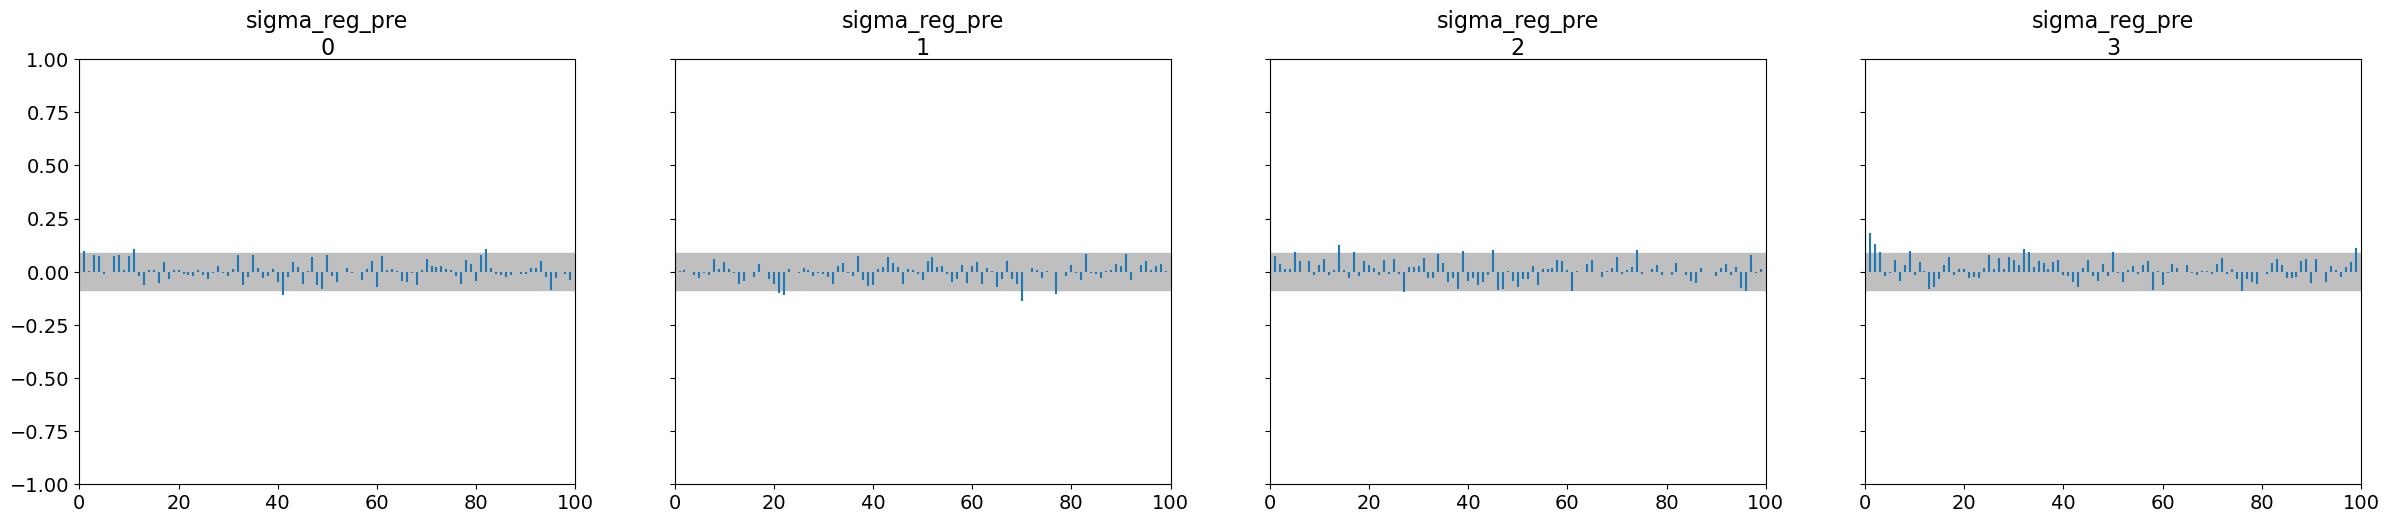

In [46]:
az.plot_autocorr(model_dict['rct'], var_names = 'sigma_reg_pre')

array([<Axes: title={'center': 'sigma_reg_pre\n0'}>,
       <Axes: title={'center': 'sigma_reg_pre\n1'}>,
       <Axes: title={'center': 'sigma_reg_pre\n2'}>,
       <Axes: title={'center': 'sigma_reg_pre\n3'}>], dtype=object)

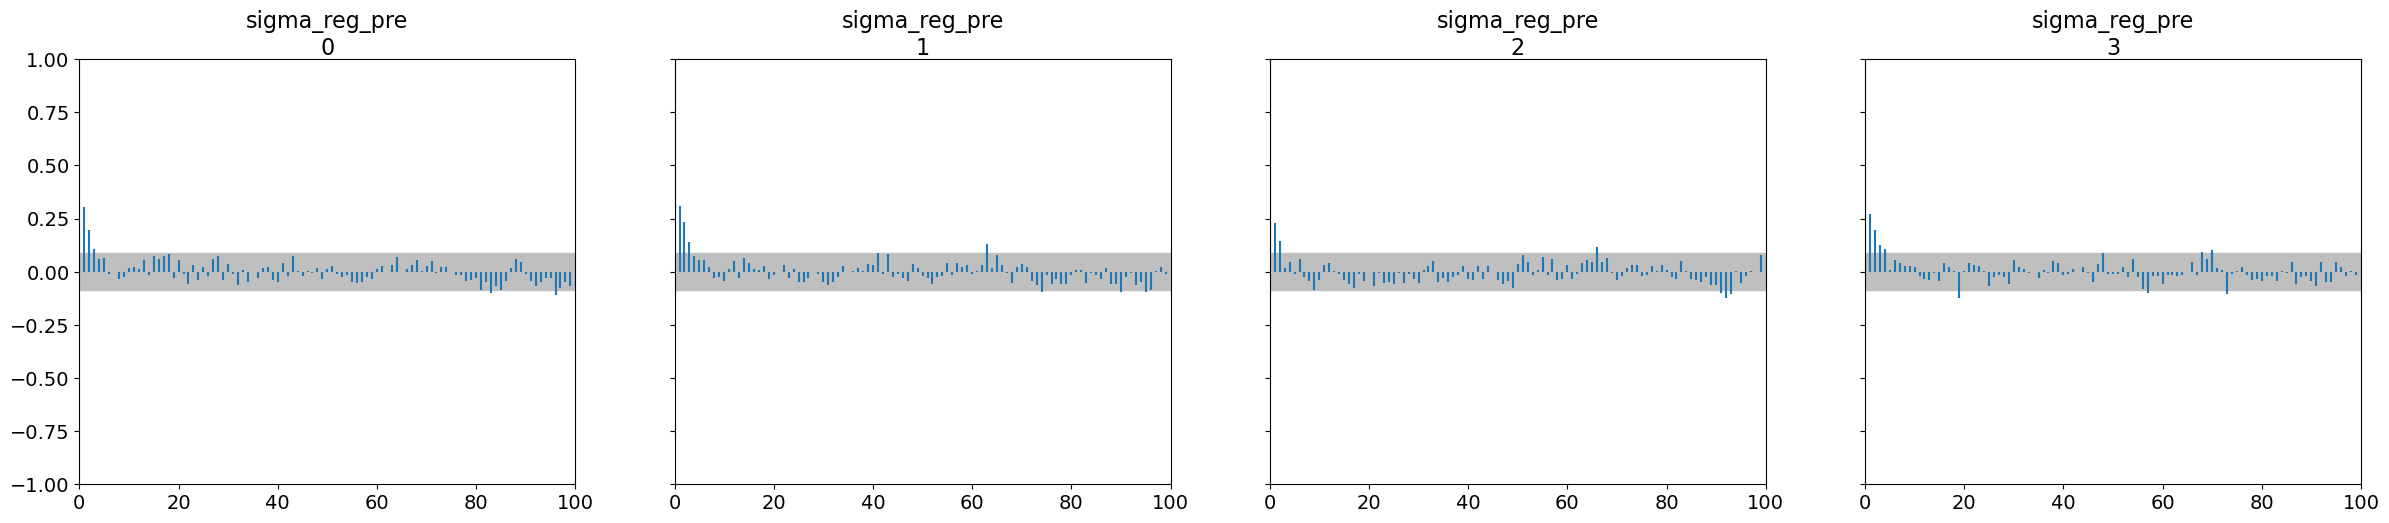

In [47]:
az.plot_autocorr(model_dict['_rct'], var_names = 'sigma_reg_pre')

In [59]:
az.summary(model_dict['rct'], var_names = ['c'] )

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"c[0, 0]",0.914,0.373,0.261,1.639,0.009,0.007,1695.0,1683.0,1.0
"c[0, 1]",2.893,0.410,2.132,3.648,0.010,0.007,1652.0,1776.0,1.0
"c[0, 2]",6.682,0.437,5.893,7.503,0.011,0.008,1667.0,1895.0,1.0
"c[1, 0]",0.664,0.320,0.089,1.285,0.007,0.005,1997.0,1871.0,1.0
"c[1, 1]",3.163,0.353,2.470,3.790,0.008,0.006,1842.0,1862.0,1.0
"c[1, 2]",6.495,0.372,5.711,7.114,0.009,0.006,1815.0,1866.0,1.0
"c[2, 0]",0.017,0.368,-0.794,0.610,0.009,0.006,1842.0,1626.0,1.0
"c[2, 1]",2.360,0.402,1.577,3.073,0.010,0.007,1685.0,1592.0,1.0
"c[2, 2]",5.802,0.416,5.057,6.614,0.010,0.007,1676.0,1823.0,1.0
"c[3, 0]",0.154,0.356,-0.484,0.817,0.008,0.006,1993.0,1792.0,1.0


In [60]:
az.summary(model_dict['_rct'], var_names = ['c'] )

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"c[0, 0]",0.911,0.375,0.196,1.612,0.009,0.006,1823.0,1791.0,1.0
"c[0, 1]",2.898,0.411,2.153,3.668,0.010,0.007,1610.0,1675.0,1.0
"c[0, 2]",6.693,0.440,5.807,7.460,0.011,0.008,1616.0,1637.0,1.0
"c[1, 0]",0.648,0.324,0.039,1.240,0.007,0.005,2198.0,1405.0,1.0
"c[1, 1]",3.158,0.355,2.545,3.876,0.008,0.006,1787.0,1553.0,1.0
"c[1, 2]",6.491,0.378,5.759,7.174,0.009,0.006,1926.0,1601.0,1.0
"c[2, 0]",0.019,0.348,-0.623,0.654,0.007,0.007,2428.0,1730.0,1.0
"c[2, 1]",2.371,0.374,1.667,3.035,0.008,0.006,2027.0,1480.0,1.0
"c[2, 2]",5.811,0.383,5.136,6.564,0.008,0.006,2068.0,1321.0,1.0
"c[3, 0]",0.137,0.358,-0.546,0.786,0.008,0.006,2094.0,1360.0,1.0
